###  Installation de l'environnement

In [1]:
%pip install -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] Aucun fichier ou dossier de ce nom: 'requirements.txt'
Note: you may need to restart the kernel to use updated packages.


### Connexion à la DB DuckDB

In [2]:
import duckdb
import os
from pathlib import Path
from typing import List
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from tqdm import tqdm
import sklearn
from sklearn.cluster import SpectralClustering
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

### Connexion à la DB / Import des Data


In [3]:
# Store database at project root
DB_NAME = Path("/home/c-enjalbert/Documents/EPSI/MSPR/bloc_2/amazing/amazing.duckdb") 
# Go up one level from current directory to get to project root
data_folder = Path("..") / "data"
# For absolute certainty, you could use the absolute path
# data_folder = Path("/home/c-enjalbert/Documents/EPSI/MSPR/bloc_2/amazing/data")
con = duckdb.connect(str(DB_NAME))

In [4]:
# 2. Query to list all tables in the database
# DuckDB specific way to list tables
tables_info = con.sql("""
    SELECT table_name
    FROM information_schema.tables
    WHERE table_schema = 'main'
    ORDER BY table_name
""").df()

print(f"Found {len(tables_info)} tables in the database:\n")

if len(tables_info) > 0:
    for i, table_name in enumerate(tables_info['table_name']):
        print(f"{i+1}. {table_name}")
else:
    print("No tables found in the database.")

Found 4 tables in the database:

1. all_events
2. loaded_files
3. user_events
4. user_segments


### Import de la table DuckDB

In [5]:
DB_NAME = "amazing.duckdb"
TABLE_EVENTS = "user_events"
TABLE_SEGMENTS = "user_segments"
SAMPLE_USER_PERCENT = 0.005
BATCH_SIZE = 1000 

In [6]:
# 5. Alternative way to show all tables
print("List of all tables using DuckDB's connections.tables():")
con.sql("SHOW TABLES").show()

List of all tables using DuckDB's connections.tables():
┌───────────────┐
│     name      │
│    varchar    │
├───────────────┤
│ all_events    │
│ loaded_files  │
│ user_events   │
│ user_segments │
└───────────────┘



In [7]:
# Examine the all_events table
print(f"First 10 rows of {TABLE_EVENTS} table:")
user_events = con.sql(f"""
    SELECT * FROM {TABLE_EVENTS} LIMIT 5000
""")
user_events.show()
user_events_df = user_events.df()


First 10 rows of user_events table:
┌───────────┬──────────────┬─────────────┬─────────────────┬─────────────────────────┬────────────────────┬────────────────────┬─────────────────────┬──────────────────────┬──────────────────────┬───────────────────────┐
│  user_id  │ total_events │ total_views │ total_purchases │ avg_time_between_events │    total_spent     │     avg_basket     │   last_event_time   │   conversion_rate    │    purchase_ratio    │ days_since_last_event │
│  varchar  │    int64     │   double    │     double      │         double          │       double       │       double       │      timestamp      │        double        │        double        │         int64         │
├───────────┼──────────────┼─────────────┼─────────────────┼─────────────────────────┼────────────────────┼────────────────────┼─────────────────────┼──────────────────────┼──────────────────────┼───────────────────────┤
│ 603627806 │          182 │       181.0 │             0.0 │       8467.90607734

### Normalisation et Standardisation des données

In [8]:
# Standardisation
print("Standardisation des features...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(user_events_df.drop(columns=["last_event_time"]))

Standardisation des features...


In [9]:
X_scaled

array([[ 1.08138408,  2.40386871,  2.63756841, ..., -0.34209879,
        -0.39384552,  0.10757825],
       [ 1.11775742,  0.827238  ,  0.89394729, ..., -0.34209879,
        -0.39384552,  1.46898354],
       [ 1.11568893,  1.41428135,  0.94843545, ..., -0.34209879,
        -0.39384552, -0.43698387],
       ...,
       [-0.98444742, -0.26298536, -0.25030408, ..., -0.34209879,
        -0.39384552, -0.16470281],
       [-0.04948455, -0.41393936, -0.39560584, ..., -0.34209879,
        -0.39384552, -0.30084334],
       [ 0.26465489, -0.27975802, -0.2684668 , ..., -0.34209879,
        -0.39384552, -0.30084334]], shape=(5000, 10))

### Fit et Analyse du Coude

### Analyse Silhouette, Calinski-Harabasz & Davies-Bouldin

/home/c-enjalbert/miniconda3/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/c-enjalbert/miniconda3/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/c-enjalbert/miniconda3/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/c-enjalbert/miniconda3/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/home/c-enjalbert/miniconda3/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may

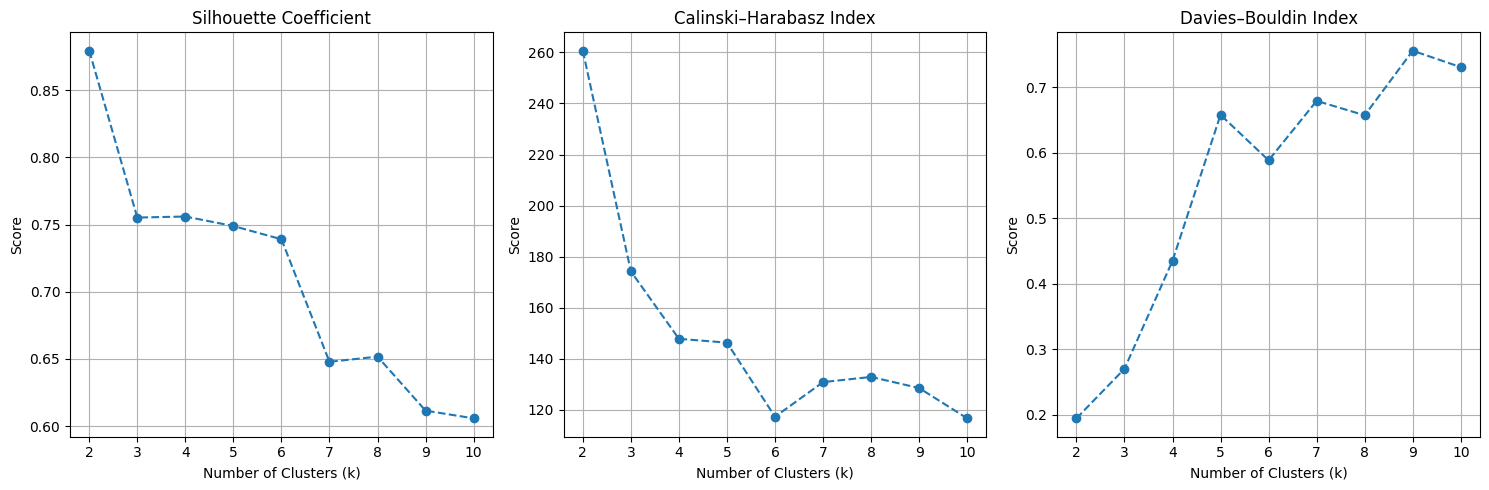

In [10]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt

# Define the range of clusters to evaluate
ks = range(2, 11)

# Initialize lists to store the scores
silhouette_scores = []
calinski_harabasz_scores = []
davies_bouldin_scores = []

# Evaluate clustering for each k
for k in ks:
    agglom = SpectralClustering(n_clusters=k)
    labels =agglom.fit_predict(X_scaled)
    
    # Compute the metrics
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(X_scaled, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_scaled, labels))

# Plot the metrics
plt.figure(figsize=(15, 5))

# Silhouette Coefficient
plt.subplot(1, 3, 1)
plt.plot(ks, silhouette_scores, marker='o', linestyle='--')
plt.title("Silhouette Coefficient")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.grid(True)

# Calinski–Harabasz Index
plt.subplot(1, 3, 2)
plt.plot(ks, calinski_harabasz_scores, marker='o', linestyle='--')
plt.title("Calinski–Harabasz Index")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.grid(True)

# Davies–Bouldin Index
plt.subplot(1, 3, 3)
plt.plot(ks, davies_bouldin_scores, marker='o', linestyle='--')
plt.title("Davies–Bouldin Index")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Score")
plt.grid(True)

plt.tight_layout()
plt.show()

### Fit et Plot KMeans pour 4, 5 et 6 Clusters

In [11]:
def kmeans_fit_and_plot(k, X_scaled, df):
    df_tmp = df.copy() 
    agglom = SpectralClustering(n_clusters=k)
    clusters = agglom.fit_predict(X_scaled)

    df_tmp["segment"] = clusters

    # --- Visualisation du clustering ---
    print("Visualisation du clustering...")
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    plt.figure(figsize=(10, 8))
    plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_tmp["segment"], cmap='tab10', s=10)
    plt.title(f"Visualisation des clusters utilisateurs (PCA)- K = {k}")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.grid(True)
    plt.show()



/home/c-enjalbert/miniconda3/lib/python3.12/site-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


Visualisation du clustering...


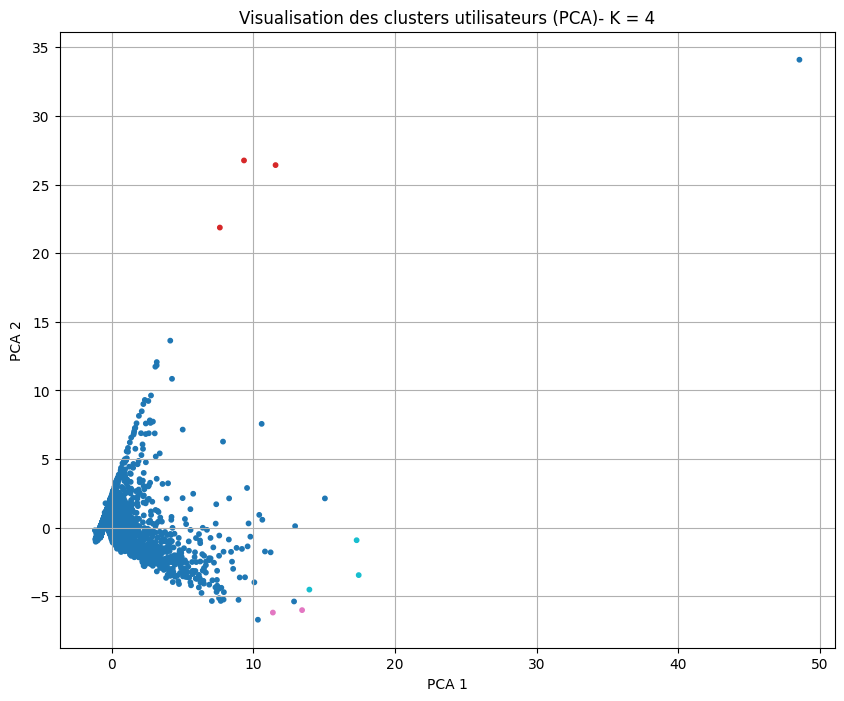

In [12]:
N_CLUSTERS = 4

kmeans_fit_and_plot(N_CLUSTERS, X_scaled, user_events_df)

### Sauvegarde du DataFrame en Table DuckDB

In [13]:
# Lister toutes les tables et colonnes des tables
print("Tables disponibles dans la base :")
tables = con.execute("SHOW TABLES").fetch_df()
print(tables)

print("Structure de la table all_events :")
schema_all_events = con.execute("DESCRIBE TABLE all_events").fetch_df()
print(schema_all_events)

print("Structure de la table user_segments :")
schema_user_segments = con.execute("DESCRIBE TABLE user_segments").fetch_df()
print(schema_user_segments)

df_purchase = con.execute("SELECT * FROM user_segments LIMIT 10").fetch_df()
print(df_purchase)



Tables disponibles dans la base :
            name
0     all_events
1   loaded_files
2    user_events
3  user_segments
Structure de la table all_events :
     column_name column_type null   key default extra
0     event_time   TIMESTAMP  YES  None    None  None
1     event_type     VARCHAR  YES  None    None  None
2     product_id     VARCHAR  YES  None    None  None
3    category_id     VARCHAR  YES  None    None  None
4  category_code     VARCHAR  YES  None    None  None
5          brand     VARCHAR  YES  None    None  None
6          price      DOUBLE  YES  None    None  None
7        user_id     VARCHAR  YES  None    None  None
8   user_session     VARCHAR  YES  None    None  None
Structure de la table user_segments :
                column_name column_type null   key default extra
0                   user_id     VARCHAR  YES  None    None  None
1              total_events      BIGINT  YES  None    None  None
2               total_views      DOUBLE  YES  None    None  None
3       

In [14]:
user_segments = con.sql(f"""
    SELECT * FROM user_segments LIMIT 5000
""")
user_segments.show()
user_segments_df = user_segments.df()

┌───────────┬──────────────┬─────────────┬─────────────────┬─────────────────────────┬─────────────┬────────────┬─────────────────────┬──────────────────────┬──────────────────────┬───────────────────────┬─────────┐
│  user_id  │ total_events │ total_views │ total_purchases │ avg_time_between_events │ total_spent │ avg_basket │   last_event_time   │   conversion_rate    │    purchase_ratio    │ days_since_last_event │ segment │
│  varchar  │    int64     │   double    │     double      │         double          │   double    │   double   │      timestamp      │        double        │        double        │         int64         │  int32  │
├───────────┼──────────────┼─────────────┼─────────────────┼─────────────────────────┼─────────────┼────────────┼─────────────────────┼──────────────────────┼──────────────────────┼───────────────────────┼─────────┤
│ 513289697 │          288 │       285.0 │             2.0 │       7233.132404181185 │       140.6 │       70.3 │ 2020-02-25 05:05:54 │ 

In [15]:
# Fermeture de la connexion DuckDB
con.close()